Задание:


1. Описание самой задачи (из хакатона) и исходных данных
2. Предобработка данных
3. Исследовательский анализ
4. Статистический анализ
5. Выбор метрик и моделей (не менее 5 моделей с подбором гиперпараметров)
6. Проверка выбранной модели на тестовых данных, сравнение с дамми-моделью
7. Выводы

Обогатительная фабрика осуществляет процессы получения вещества с высоким содержания никеля и меди (относительно содержаний в руде). Для этого выполняется пенная *флотация*: в бочку поступает пульпа (частицы руды, вода и реагенты), за счёт физико-химических процессов происходит вытеснение частиц с б***о***льшим содержанием в пенный продукт (концентрат) и продвижение оставшейся части к следующей бочке (хвост).

Несколько бочек объединяются во флотомашины (ФМ) с определенной специализацией. Концентрат и хвосты отдельно друг от друга подвергаются сгущению и поступают на вход последующих флотомашин – вплоть до готового продукта. Основная бизнес-метрика процесса – извлечение металла в готовый концентрат. На отдельных стадиях в бочки подаются различные реагенты, воздух и регулируется рабочий объём пульпы в бочке. Также для флотомашин определены рабочие диапазоны (наибольшее и наименьшее допустимые значения) для содержания металлов в продуктах – концентратах и хвостах. Эти диапазоны изменяются в условиях изменений свойств руды на входе фабрики.




Формат имен признаков в датасете df_hack_final:

    Ni_rec – извлечение никеля в готовый никелевый продукт, концентрат (значение может отсутствовать, валидны только меньше 1 и больше 0),
    
    Ore, oreth – имена, которые означают признаки рудного сгустителя (Ore thickener) и на входе первой ФМ (напомним, ФМ – флотомашина),
    
    resth – имена, которые означают признаки сгустителя с готовым никелевым продуктом (Final Ni thickener).

Физические характеристики:
Mass (масса),
Dens (плотность),
Vol (объём),
Ni (никель),
Cu (медь),
A (флаг автоуправления, если оптимизатор управления ФМ включен, то равен 1 – фактические диапазоны на этой ФМ актуальны, в противном случае диапазонам не следует доверять, так как не обновлялись после выключения оптимизатора).
Суффиксы имён ФМ (положения в цепи агрегатов): 1.1, 1.2, …, 6.2. Суффиксы продуктов: F – питание ФМ, C – концентрат ФМ, T – хвосты ФМ. Суффиксы границ фактических диапазонов, которые были выставлены технологом для оптимизатора ФМ: min, max. Границы фактического диапазона в файле исходных данных – значения, которые выставляли технологи производства для сервиса оптимизации флотации (по одному на каждую линию флотомашины, например, оптимизатор для ФМ1.1.), чтобы этот оптимизатор генерировал воздействия на рычаги управления флотацией на ФМ, которые обеспечат сходимость к середине этого диапазона.
Технологические ограничения, которым должно соответствовать решение:
Ограничение 1. Каждый диапазон (признаки min, max) можно изменить не чаще 1 раза в 2 часа (не менее 8 15-минуток подряд с одной и той же парой значений границ).
Ограничение 2. Наименьшие допустимые приращения признаков min, max зависят от продукта, металла и ФМ (и одинаковы для двух линий одной ФМ). В качестве приращений используйте только кратные им значения (например, если наименьшее допустимое – 0.1, используйте 0.1, 0.2, 0.3, …):


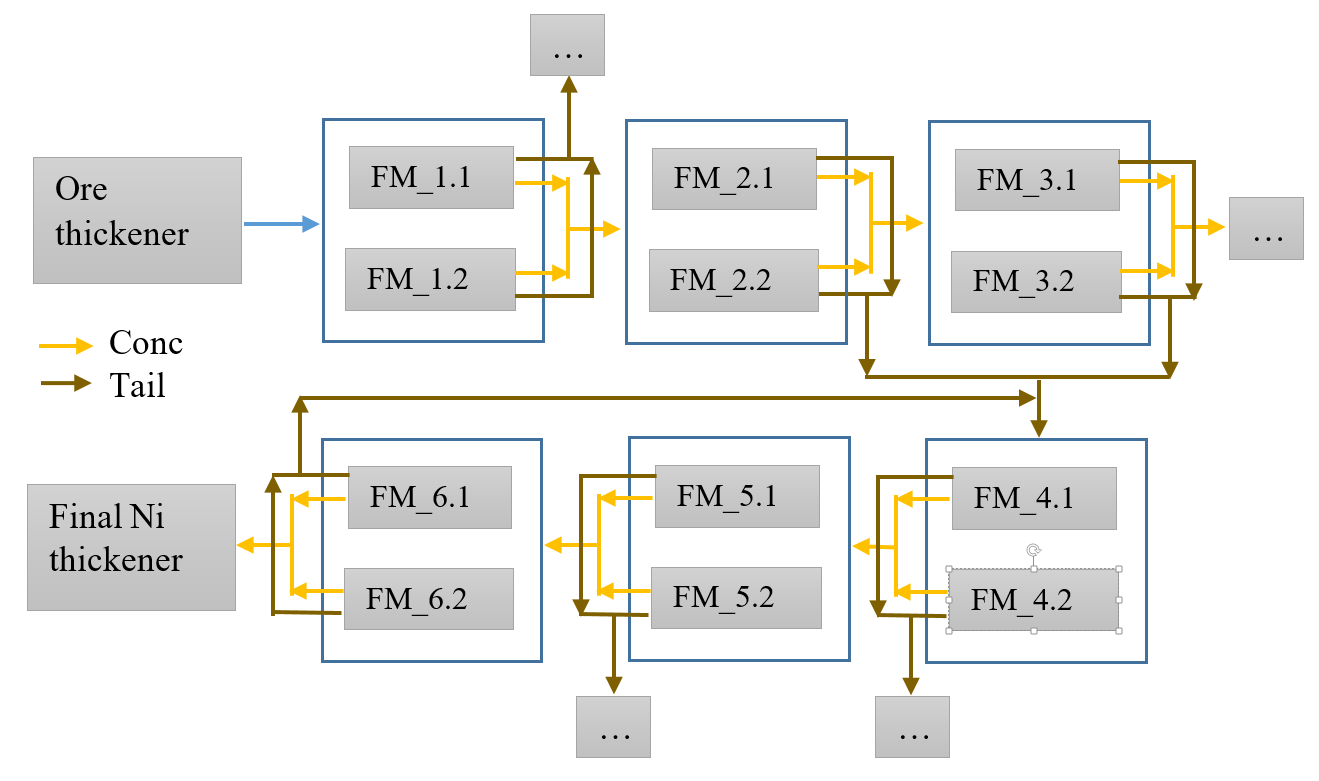

In [ ]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import phik
from phik.report import plot_correlation_matrix
from phik import report



In [ ]:

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

from sklearn.datasets import make_regression

In [ ]:
dataTest=pd.read_csv('/content/test.csv',index_col='MEAS_DT')
pd.set_option('display.max_columns', None)
dataTest

,Ni_1.1C_min,Ni_1.1C_max,Cu_1.1C_min,Cu_1.1C_max,Ni_1.2C_min,Ni_1.2C_max,Cu_1.2C_min,Cu_1.2C_max,Cu_2.1T_min,Cu_2.1T_max,Cu_2.2T_min,Cu_2.2T_max,Cu_3.1T_min,Cu_3.1T_max,Cu_3.2T_min,Cu_3.2T_max,Ni_4.1T_min,Ni_4.1T_max,Ni_4.1C_min,Ni_4.1C_max,Ni_4.2T_min,Ni_4.2T_max,Ni_4.2C_min,Ni_4.2C_max,Ni_5.1T_min,Ni_5.1T_max,Ni_5.1C_min,Ni_5.1C_max,Ni_5.2T_min,Ni_5.2T_max,Ni_5.2C_min,Ni_5.2C_max,Ni_6.1T_min,Ni_6.1T_max,Ni_6.1C_min,Ni_6.1C_max,Ni_6.2T_min,Ni_6.2T_max,Ni_6.2C_min,Ni_6.2C_max
MEAS_DT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-19 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-19 12:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-19 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-19 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-19 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-05 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-05 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-05 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data=pd.read_csv('/content/df_hack_final.csv',index_col='MEAS_DT')
pd.set_option('display.max_columns', None)
data

,Cu_oreth,Ni_oreth,Ore_mass,Mass_1,Mass_2,Dens_4,Mass_4,Vol_4,Cu_4F,Ni_4F,Ni_4.1C,Ni_4.1C_max,Ni_4.1C_min,Ni_4.1T,Ni_4.1T_max,Ni_4.1T_min,FM_4.1_A,Ni_4.2C,Ni_4.2C_max,Ni_4.2C_min,Ni_4.2T,Ni_4.2T_max,Ni_4.2T_min,FM_4.2_A,Dens_5,Mass_5,Vol_5,Ni_5F,Ni_5.1C,Ni_5.1C_max,Ni_5.1C_min,Ni_5.1T,Ni_5.1T_max,Ni_5.1T_min,FM_5.1_A,Ni_5.2C,Ni_5.2C_max,Ni_5.2C_min,Ni_5.2T,Ni_5.2T_max,Ni_5.2T_min,FM_5.2_A,Dens_6,Mass_6,Vol_6,Ni_6F,Ni_6.1C,Ni_6.1C_max,Ni_6.1C_min,Ni_6.1T,Ni_6.1T_max,Ni_6.1T_min,FM_6.1_A,Ni_6.2C,Ni_6.2C_max,Ni_6.2C_min,Ni_6.2T,Ni_6.2T_max,Ni_6.2T_min,FM_6.2_A,Cu_resth,Ni_resth,Cu_1.1C,Ni_1.1C,Cu_1.2C,Ni_1.2C,Cu_2F,Ni_2F,Cu_2.1C,Ni_2.1C,Cu_2.2C,Ni_2.2C,Cu_3F,Ni_3F,Cu_3.1C,Ni_3.1C,Cu_3.2C,Ni_3.2C,Cu_2.1T,Ni_2.1T,Cu_2.2T,Ni_2.2T,Cu_3.1T,Ni_3.1T,Cu_3.2T,Ni_3.2T,Dens_3,Dens_1,Dens_2,Mass_3,FM_1.1_A,Cu_1.1C_max,Cu_1.1C_min,Ni_1.1C_max,Ni_1.1C_min,Ni_1.1T_max,Ni_1.1T_min,FM_1.2_A,Cu_1.2C_max,Cu_1.2C_min,Ni_1.2C_max,Ni_1.2C_min,Ni_1.2T_max,Ni_1.2T_min,FM_2.1_A,Cu_2.1C_max,Cu_2.1C_min,Cu_2.1T_max,Cu_2.1T_min,FM_2.2_A,Cu_2.2C_max,Cu_2.2C_min,Cu_2.2T_max,Cu_2.2T_min,FM_3.1_A,Cu_3.1C_max,Cu_3.1C_min,Ni_3.1C_max,Ni_3.1C_min,Cu_3.1T_max,Cu_3.1T_min,FM_3.2_A,Cu_3.2C_max,Cu_3.2C_min,Ni_3.2C_max,Ni_3.2C_min,Cu_3.2T_max,Cu_3.2T_min,Ni_rec
MEAS_DT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,2.6097,1.5313,1096.5,1240.597656,692.090942,1.342155,711.999023,1548.71875,0.6232,2.4937,4.1826,NaN,NaN,0.7136,NaN,NaN,NaN,3.8121,NaN,NaN,0.7602,NaN,NaN,NaN,1.346855,476.127625,1021.624939,3.99735,6.2100,NaN,NaN,0.7943,NaN,NaN,NaN,6.7906,NaN,NaN,0.7694,NaN,NaN,NaN,1.344661,219.958878,474.96875,9.09595,9.0939,NaN,NaN,1.3531,NaN,NaN,NaN,9.0980,NaN,NaN,1.2932,NaN,NaN,NaN,1.8008,8.2067,4.4612,2.5949,5.0066,2.9721,4.5836,2.7272,18.0072,2.8705,17.5073,2.5247,13.5003,2.8885,14.3382,2.8217,14.9352,2.7402,0.6405,2.0980,0.4005,2.7056,1.6723,3.9535,1.7310,4.4555,0.808328,1.388724,1.397016,1159.946120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 00:15:00,2.5548,1.4842,1123.0,1205.422363,693.616394,1.339809,710.697815,1556.56250,0.6292,2.5157,4.1037,4.7,4.5,0.7247,0.77,0.67,0.0,3.7383,4.7,4.2,0.7585,0.75,0.68,0.0,1.342700,473.042267,1027.312500,3.92100,6.3300,6.5,6.3,0.8009,0.75,0.68,0.0,6.6420,6.5,6.3,0.7743,0.75,0.65,0.0,1.335838,275.753723,611.09375,9.02795,9.0422,9.5,9.0,1.3338,1.45,1.4,0.0,9.0137,9.5,9.0,1.3044,1.5,1.4,0.0,1.8160,7.8830,4.5157,2.5875,5.1750,3.0450,4.4472,2.7258,18.1457,2.8092,17.4514,2.4793,13.4167,2.9271,14.1753,2.8282,14.6916,2.7704,0.6740,2.0389,0.3986,2.7757,1.4766,3.9686,1.8037,4.2734,0.807156,1.375562,1.397872,1189.409024,0.0,5.0,4.7,3.2,2.7,0.15,0.12,0.0,5.0,4.7,3.2,2.7,0.15,0.12,0.0,17.0,16.0,0.45,0.34,0.0,17.0,16.0,0.42,0.34,0.0,15.5,14.5,3.9,3.7,1.0,0.8,0.0,14.0,12.0,3.7,3.5,1.2,1.00,NaN
2024-01-01 00:30:00,2.5109,1.4355,840.0,1188.762573,698.350586,1.339792,707.198547,1548.09375,0.5941,2.5253,4.1911,4.7,4.5,0.7069,0.77,0.67,0.0,3.7132,4.7,4.2,0.7613,0.75,0.68,0.0,1.342700,472.912659,1026.937500,3.95215,6.2619,6.5,6.3,0.7829,0.75,0.68,0.0,6.5325,6.5,6.3,0.7582,0.75,0.65,0.0,1.312747,263.925659,626.93750,8.95510,8.9666,9.5,9.0,1.2827,1.45,1.4,0.0,8.9436,9.5,9.0,1.2598,1.5,1.4,0.0,1.9386,7.7173,4.4968,2.6646,5.1975,3.0923,4.4774,2.7327,16.3150,2.7114,17.3994,2.4534,13.6483,2.8914,13.9210,2.8325,14.5276,2.7553,0.7055,2.0604,0.3968,2.7219,1.2512,4.0164,1.6489,4.4432,0.797312,1.371214,1.399892,1247.048316,0.0,5.0,4.7,3.2,2.7,0.15,0.12,0.0,5.0,4.7,3.2,2.7,0.15,0.12,0.0,17.0,16.0,0.45,0.34,0.0,17.0,16.0,0.42,0.34,0.0,15.5,14.5,3.9,3.7,1.0,0.8,0.0,14.0,12.0,3.7,3.5,1.2,1.00,0.970170
2024-01-01 00:45:00,2.4765,1.3852,824.0,1151.888672,714.678101,1.342392,707.865540,1538.87500,0.6682,2.5418,4.1268,4.7,4.5,0.7097,0.77,0.67,0.0,3.7086,4.7,4.2,0.7412,0.75,0.68,0.0,1.342075,475.598877,1034.750000,3.91770,6.0307,6.5,6.3,0.7576,0.75,0.

In [ ]:
percentage = data.isna().mean().round(4) * 100

with  pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(percentage.sort_values(ascending=False))

Cu_3F          22.22
Ni_3F          22.22
Ni_1.1C        19.83
Cu_1.1C        19.83
Cu_2F          19.47
Ni_2F          19.47
Ni_5F          19.41
Cu_3.1C        19.35
Ni_3.1C        19.35
Ni_2.2T        19.10
Cu_2.2T        19.10
Ni_3.1T        19.04
Cu_3.1T        19.04
Ni_4.2C        18.96
Ni_5.1T        18.81
Ni_4.2T        18.81
Cu_2.1T        18.75
Ni_2.1T        18.75
Ni_4F          14.02
Cu_4F          14.02
Ni_oreth       13.59
Cu_oreth       13.59
Ni_resth       12.92
Cu_resth       12.92
Ni_6.1T        11.81
Ni_6.2T        11.61
Ni_4.1T        11.58
Ni_5.2T        11.38
Cu_3.2C        11.35
Ni_3.2C        11.35
Ni_6F          10.44
Ni_6.2C         9.66
Cu_2.1C         9.58
Ni_2.1C         9.58
Ni_rec          8.49
Cu_1.2C         4.77
Ni_1.2C         4.77
Ni_2.2C         4.35
Cu_2.2C         4.35
Ni_5.2C         4.06
Ni_6.1C         3.73
Cu_3.2T         3.68
Ni_3.2T         3.68
Ni_4.1C         3.36
Ni_5.1C         3.25
Cu_3.2T_max     0.00
FM_1.2_A        0.00
FM_2.1_A     

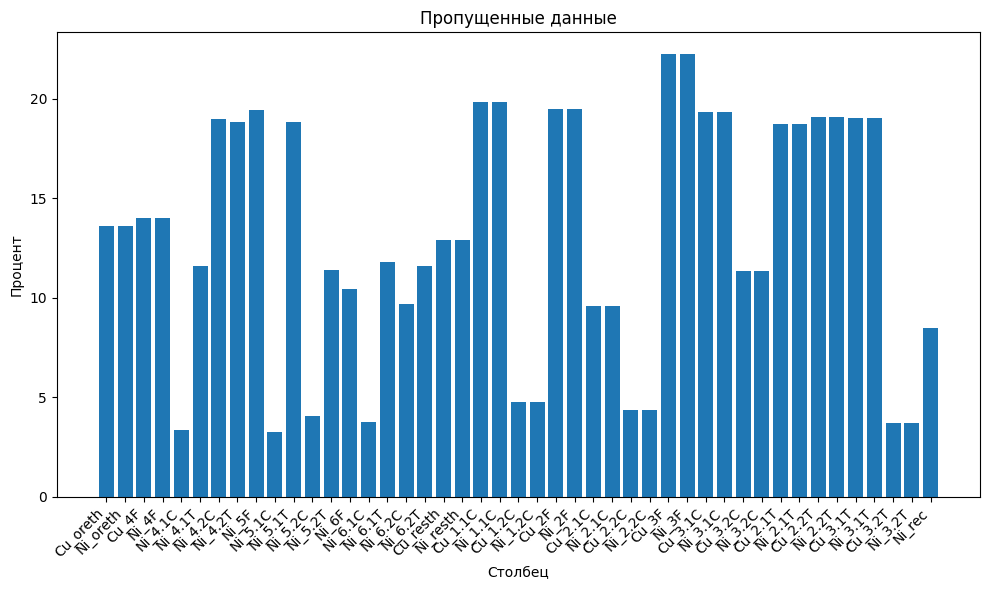

In [ ]:
#Проценты пропущенных данных
percentage_positive = percentage[percentage > 0]

plt.figure(figsize=(10, 6))
plt.bar(percentage_positive.index, percentage_positive.values)
plt.xlabel("Столбец")
plt.ylabel("Процент")
plt.title("Пропущенные данные")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
#Смотрю, строк с ni_rec, больше или равно 1
rows_num = data[data['Ni_rec'] >=1].shape[0]
print(f"Ni_rec >= 1: {rows_num}")

Ni_rec >= 1: 956


In [ ]:
#Удаляю столбцы, где ni_rec больше или равно 1, т.к по условию значения должны быть между 0 и 1
data = data[data['Ni_rec'] < 1]


In [ ]:
#Заполняю средними значениями прпущенные
data=data.fillna(data.median())

In [ ]:
column_1_1 = ['Cu_1.1C_max', 'Cu_1.1C_min', 'Ni_1.1C_min', 'Ni_1.1C_max', 'Cu_1.1C', 'Ni_1.1C', 'Ni_1.1T_max', 'Ni_1.1T_min', 'Ni_rec', 'Ni_oreth', 'Ore_mass', 'Mass_1', 'Cu_resth', 'Ni_resth', 'Cu_oreth']
column_1_2 = ['Cu_1.2C_max', 'Cu_1.2C_min', 'Ni_1.2C_min', 'Ni_1.2C_max', 'Cu_1.2C', 'Ni_1.2C', 'Ni_1.2T_max', 'Ni_1.2T_min', 'Ni_rec', 'Ni_oreth', 'Ore_mass', 'Mass_1', 'Cu_resth', 'Ni_resth', 'Cu_oreth']
column_2_1 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Mass_2', 'Cu_resth', 'Ni_resth','Cu_2F', 'Ni_2F', 'Cu_2.1C', 'Ni_2.1C', 'Cu_2.1T', 'Ni_2.1T', 'Dens_2', 'FM_2.1_A', 'Cu_2.1C_max', 'Cu_2.1C_min', 'Cu_2.1T_max','Cu_2.1T_min', 'Ni_rec']
column_2_2 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Mass_2', 'Cu_resth', 'Ni_resth', 'Cu_2F', 'Ni_2F', 'Cu_2.2C', 'Ni_2.2C', 'Cu_2.2T', 'Ni_2.2T', 'Dens_2', 'FM_2.2_A', 'Cu_2.2C_max', 'Cu_2.2C_min', 'Cu_2.2T_max', 'Cu_2.2T_min', 'Ni_rec']
column_3_1 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Cu_3F', 'Ni_3F', 'Cu_3.1C', 'Ni_3.1C', 'Cu_3.1T', 'Ni_3.1T', 'Dens_3', 'Mass_3', 'FM_3.1_A', 'Cu_3.1C_max', 'Cu_3.1C_min', 'Ni_3.1C_max', 'Ni_3.1C_min', 'Cu_3.1T_max', 'Cu_3.1T_min', 'Ni_rec']
column_3_2 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Cu_3F', 'Ni_3F','Cu_3.2C', 'Ni_3.2C', 'Cu_3.2T', 'Ni_3.2T', 'Dens_3', 'Mass_3', 'FM_3.2_A', 'Cu_3.2C_max', 'Cu_3.2C_min', 'Ni_3.2C_max', 'Ni_3.2C_min', 'Cu_3.2T_max', 'Cu_3.2T_min', 'Ni_rec']
column_4_1 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_4', 'Mass_4', 'Vol_4', 'Cu_4F', 'Ni_4F', 'Ni_4.1C', 'Ni_4.1C_max', 'Ni_4.1C_min', 'Ni_4.1T', 'Ni_4.1T_max', 'Ni_4.1T_min', 'FM_4.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']
column_4_2 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_4', 'Mass_4', 'Vol_4', 'Cu_4F', 'Ni_4F', 'Ni_4.2C', 'Ni_4.2C_max', 'Ni_4.2C_min', 'Ni_4.2T', 'Ni_4.2T_max', 'Ni_4.2T_min', 'FM_4.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']
column_5_1 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_5', 'Mass_5', 'Vol_5', 'Ni_5F', 'Ni_5.1C', 'Ni_5.1C_max', 'Ni_5.1C_min', 'Ni_5.1T', 'Ni_5.1T_max', 'Ni_5.1T_min', 'FM_5.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']
column_5_2 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_5', 'Mass_5', 'Vol_5', 'Ni_5F', 'Ni_5.2C', 'Ni_5.2C_max', 'Ni_5.2C_min', 'Ni_5.2T', 'Ni_5.2T_max', 'Ni_5.2T_min', 'FM_5.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']
column_6_1 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_6', 'Mass_6', 'Vol_6', 'Ni_6F', 'Ni_6.1C', 'Ni_6.1C_max', 'Ni_6.1C_min', 'Ni_6.1T', 'Ni_6.1T_max', 'Ni_6.1T_min', 'FM_6.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']
column_6_2 = ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_6', 'Mass_6', 'Vol_6', 'Ni_6F', 'Ni_6.2C', 'Ni_6.2C_max', 'Ni_6.2C_min', 'Ni_6.2T', 'Ni_6.2T_max', 'Ni_6.2T_min', 'FM_6.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


interval columns not set, guessing: ['Cu_1.1C_max', 'Cu_1.1C_min', 'Ni_1.1C_min', 'Ni_1.1C_max', 'Cu_1.1C', 'Ni_1.1C', 'Ni_1.1T_max', 'Ni_1.1T_min', 'Ni_rec', 'Ni_oreth', 'Ore_mass', 'Mass_1', 'Cu_resth', 'Ni_resth', 'Cu_oreth']


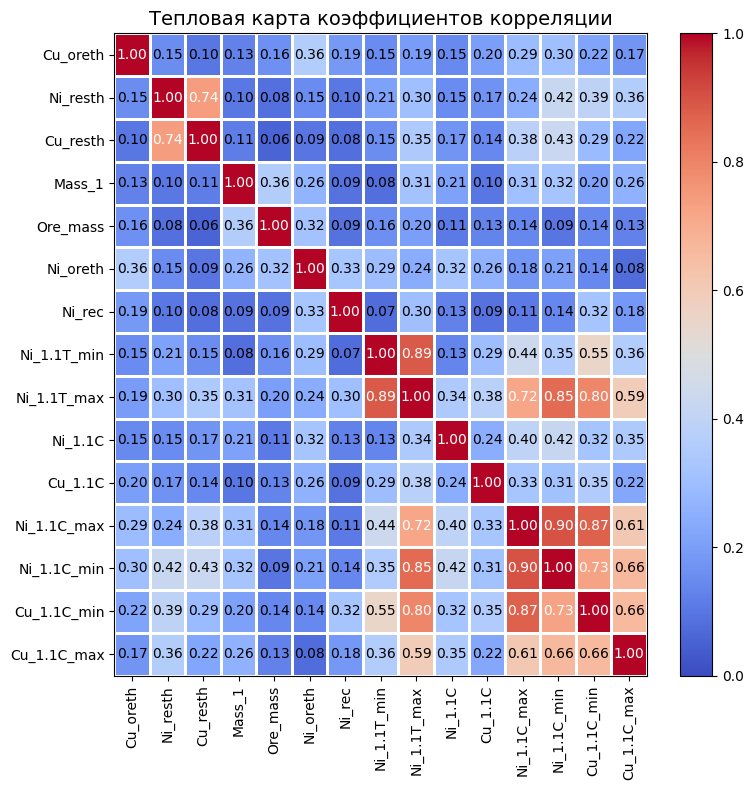

interval columns not set, guessing: ['Cu_1.2C_max', 'Cu_1.2C_min', 'Ni_1.2C_min', 'Ni_1.2C_max', 'Cu_1.2C', 'Ni_1.2C', 'Ni_1.2T_max', 'Ni_1.2T_min', 'Ni_rec', 'Ni_oreth', 'Ore_mass', 'Mass_1', 'Cu_resth', 'Ni_resth', 'Cu_oreth']


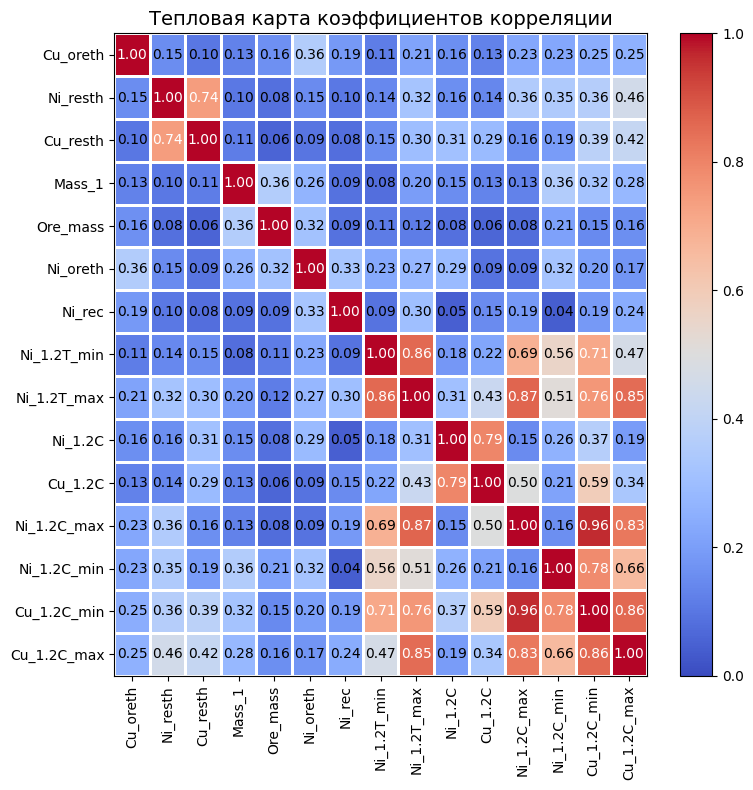

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Mass_2', 'Cu_resth', 'Ni_resth', 'Cu_2F', 'Ni_2F', 'Cu_2.1C', 'Ni_2.1C', 'Cu_2.1T', 'Ni_2.1T', 'Dens_2', 'FM_2.1_A', 'Cu_2.1C_max', 'Cu_2.1C_min', 'Cu_2.1T_max', 'Cu_2.1T_min', 'Ni_rec']


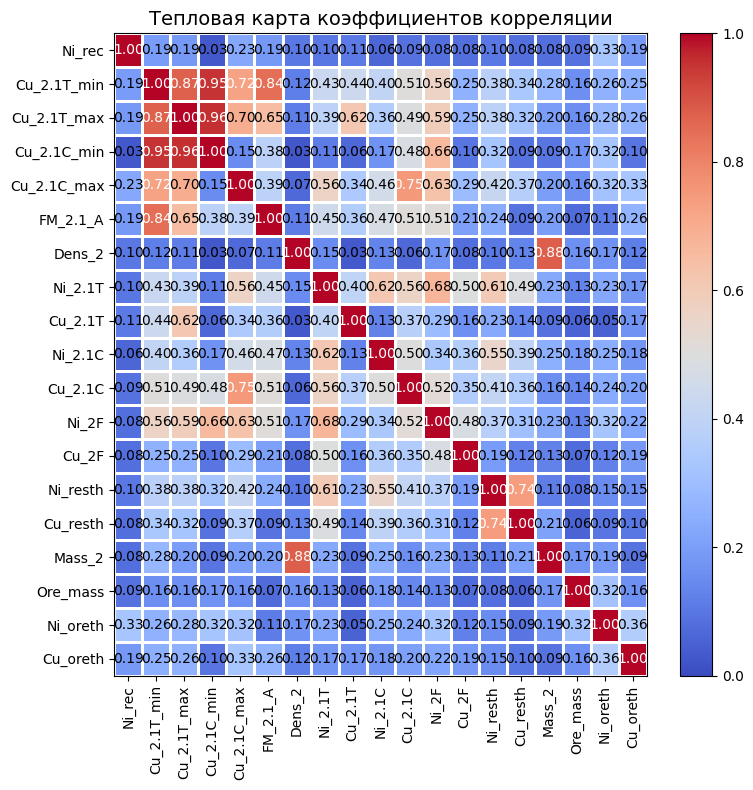

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Mass_2', 'Cu_resth', 'Ni_resth', 'Cu_2F', 'Ni_2F', 'Cu_2.2C', 'Ni_2.2C', 'Cu_2.2T', 'Ni_2.2T', 'Dens_2', 'FM_2.2_A', 'Cu_2.2C_max', 'Cu_2.2C_min', 'Cu_2.2T_max', 'Cu_2.2T_min', 'Ni_rec']


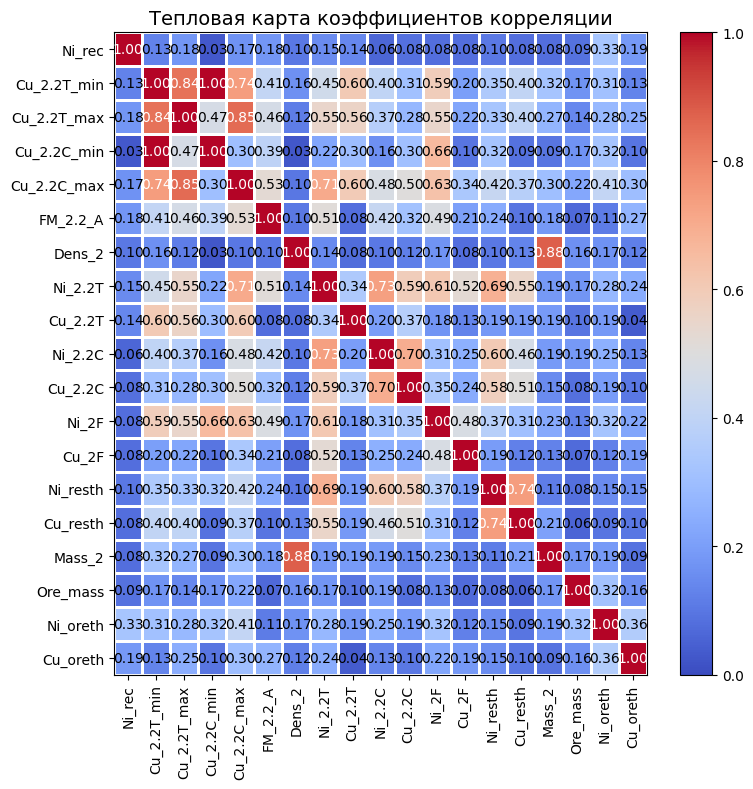

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Cu_3F', 'Ni_3F', 'Cu_3.1C', 'Ni_3.1C', 'Cu_3.1T', 'Ni_3.1T', 'Dens_3', 'Mass_3', 'FM_3.1_A', 'Cu_3.1C_max', 'Cu_3.1C_min', 'Ni_3.1C_max', 'Ni_3.1C_min', 'Cu_3.1T_max', 'Cu_3.1T_min', 'Ni_rec']


/usr/local/lib/python3.10/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable Ni_3.1C_max for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable Ni_3.1C_min for analysis 1. Dropping this column
  warnings.warn(


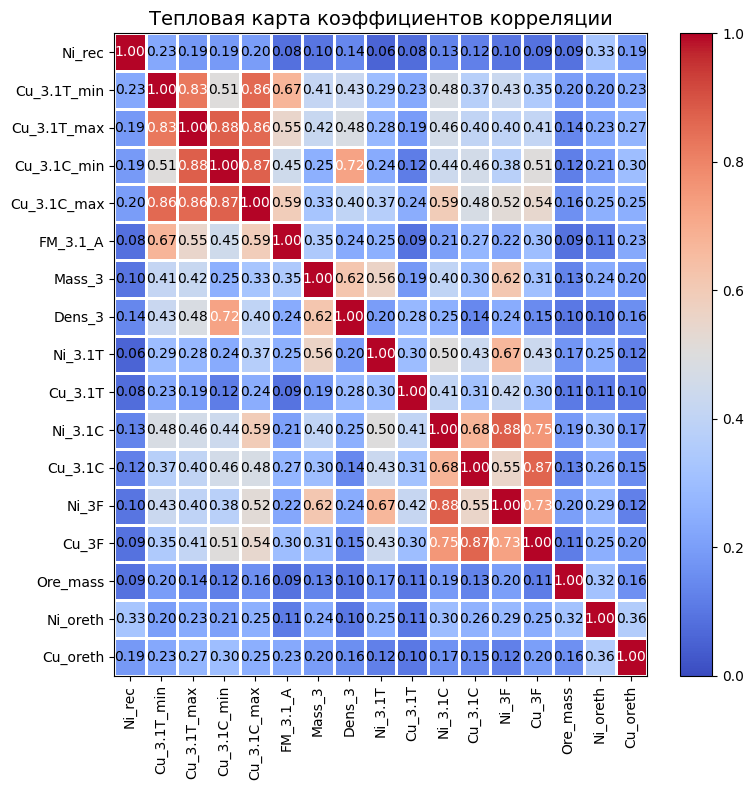

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Cu_3F', 'Ni_3F', 'Cu_3.2C', 'Ni_3.2C', 'Cu_3.2T', 'Ni_3.2T', 'Dens_3', 'Mass_3', 'FM_3.2_A', 'Cu_3.2C_max', 'Cu_3.2C_min', 'Ni_3.2C_max', 'Ni_3.2C_min', 'Cu_3.2T_max', 'Cu_3.2T_min', 'Ni_rec']


/usr/local/lib/python3.10/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable Ni_3.2C_max for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable Ni_3.2C_min for analysis 1. Dropping this column
  warnings.warn(


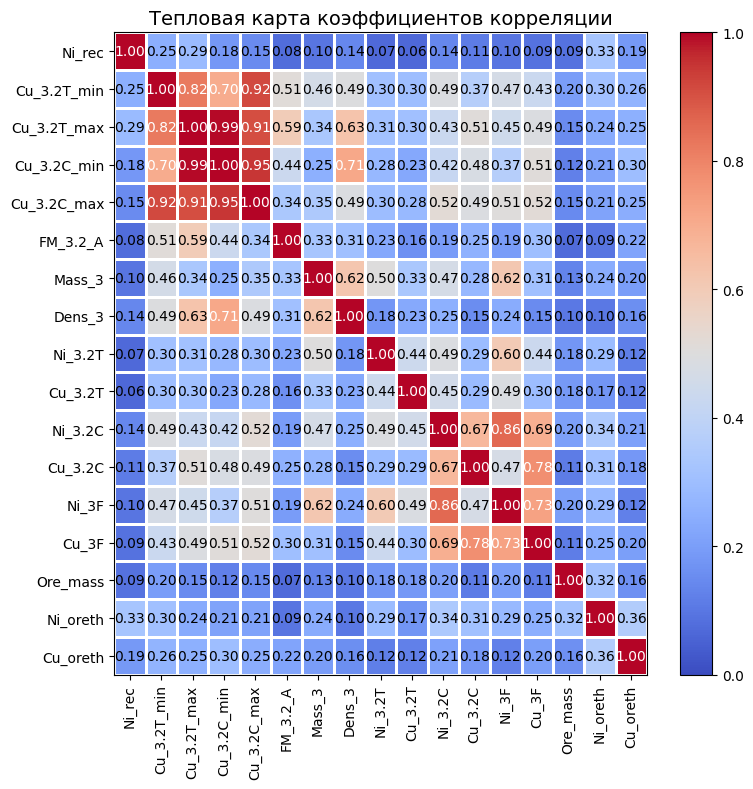

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_4', 'Mass_4', 'Vol_4', 'Cu_4F', 'Ni_4F', 'Ni_4.1C', 'Ni_4.1C_max', 'Ni_4.1C_min', 'Ni_4.1T', 'Ni_4.1T_max', 'Ni_4.1T_min', 'FM_4.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


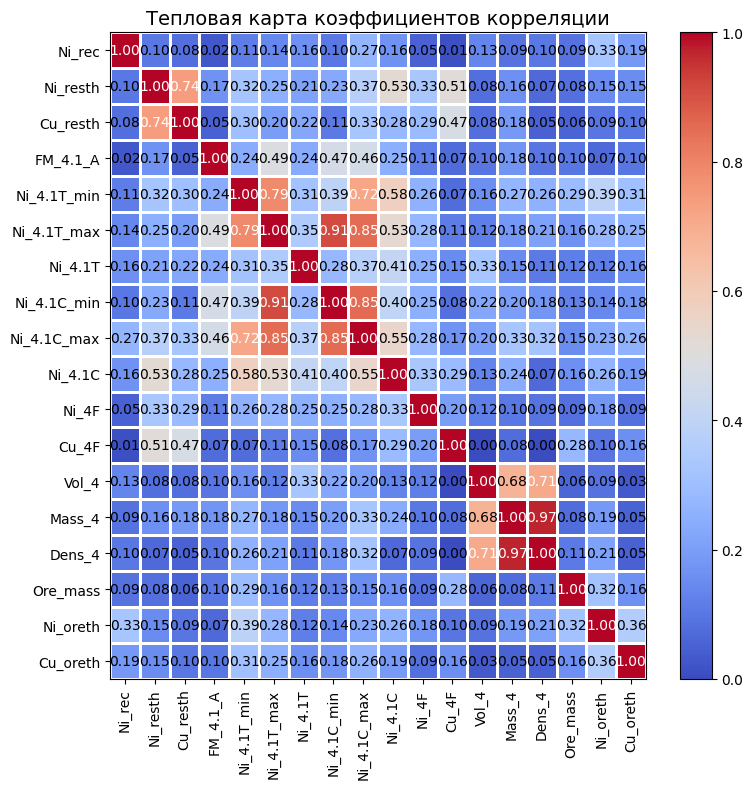

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_4', 'Mass_4', 'Vol_4', 'Cu_4F', 'Ni_4F', 'Ni_4.2C', 'Ni_4.2C_max', 'Ni_4.2C_min', 'Ni_4.2T', 'Ni_4.2T_max', 'Ni_4.2T_min', 'FM_4.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


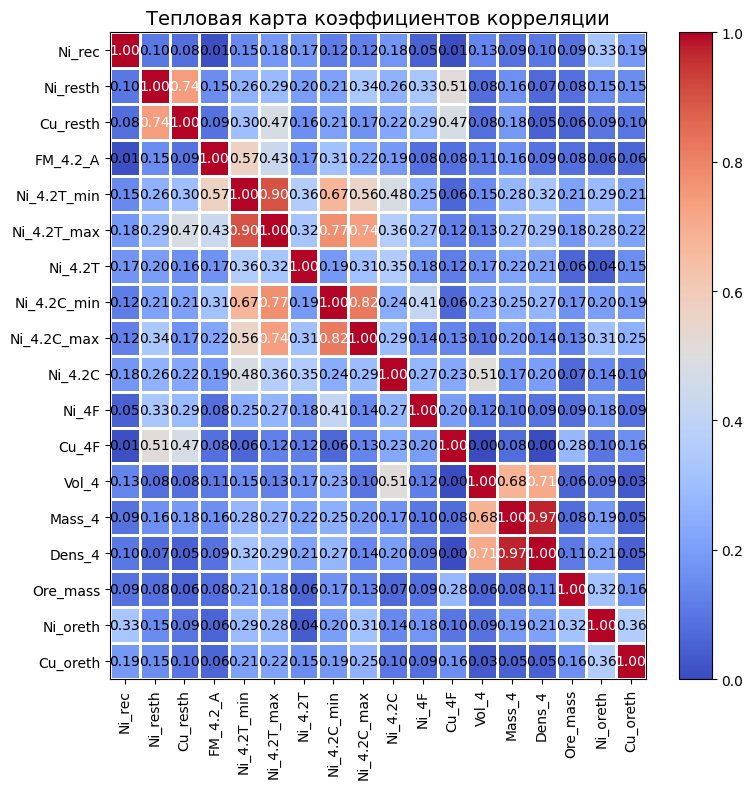

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_5', 'Mass_5', 'Vol_5', 'Ni_5F', 'Ni_5.1C', 'Ni_5.1C_max', 'Ni_5.1C_min', 'Ni_5.1T', 'Ni_5.1T_max', 'Ni_5.1T_min', 'FM_5.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


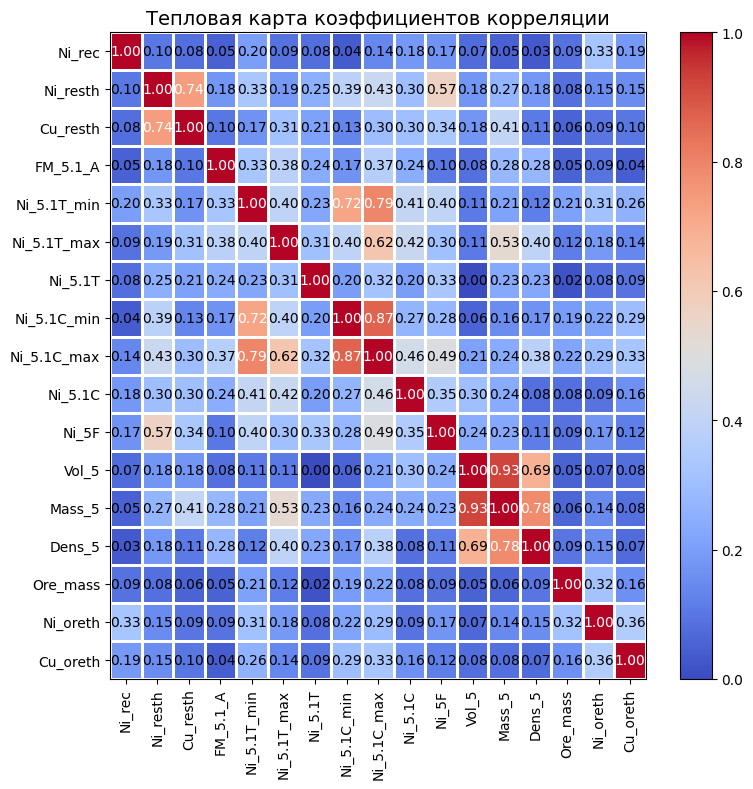

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_5', 'Mass_5', 'Vol_5', 'Ni_5F', 'Ni_5.2C', 'Ni_5.2C_max', 'Ni_5.2C_min', 'Ni_5.2T', 'Ni_5.2T_max', 'Ni_5.2T_min', 'FM_5.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


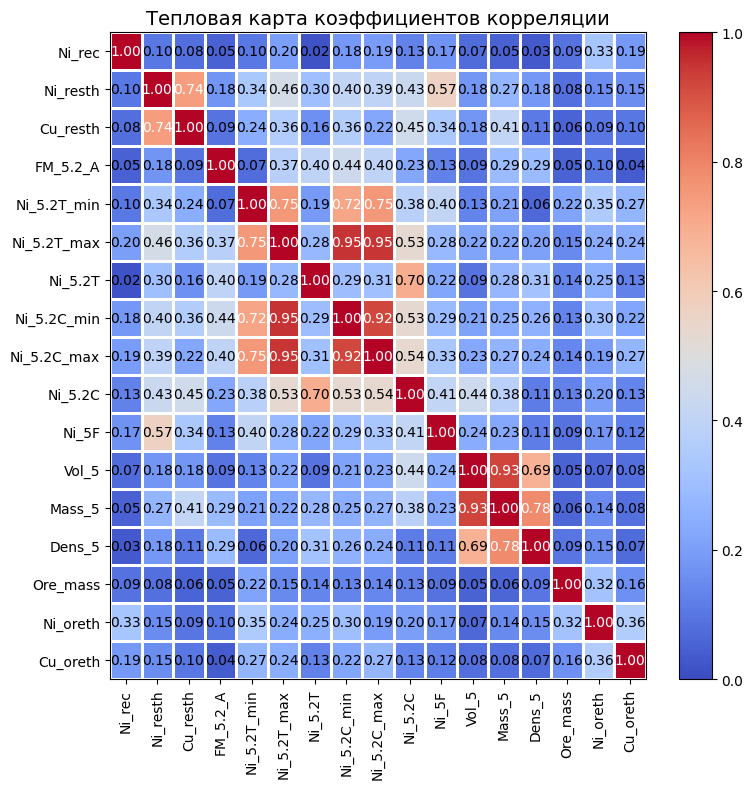

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_6', 'Mass_6', 'Vol_6', 'Ni_6F', 'Ni_6.1C', 'Ni_6.1C_max', 'Ni_6.1C_min', 'Ni_6.1T', 'Ni_6.1T_max', 'Ni_6.1T_min', 'FM_6.1_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


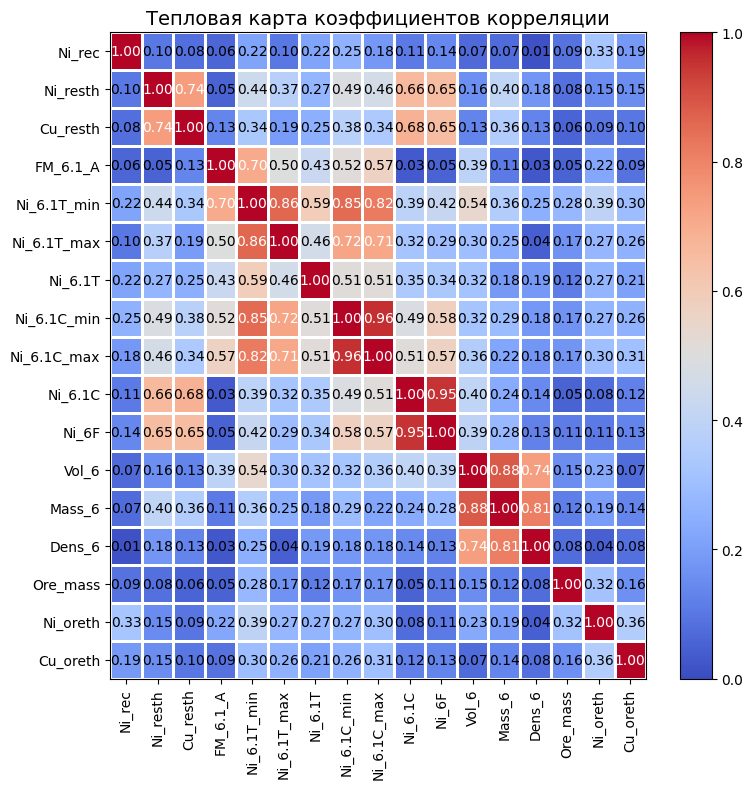

interval columns not set, guessing: ['Cu_oreth', 'Ni_oreth', 'Ore_mass', 'Dens_6', 'Mass_6', 'Vol_6', 'Ni_6F', 'Ni_6.2C', 'Ni_6.2C_max', 'Ni_6.2C_min', 'Ni_6.2T', 'Ni_6.2T_max', 'Ni_6.2T_min', 'FM_6.2_A', 'Cu_resth', 'Ni_resth', 'Ni_rec']


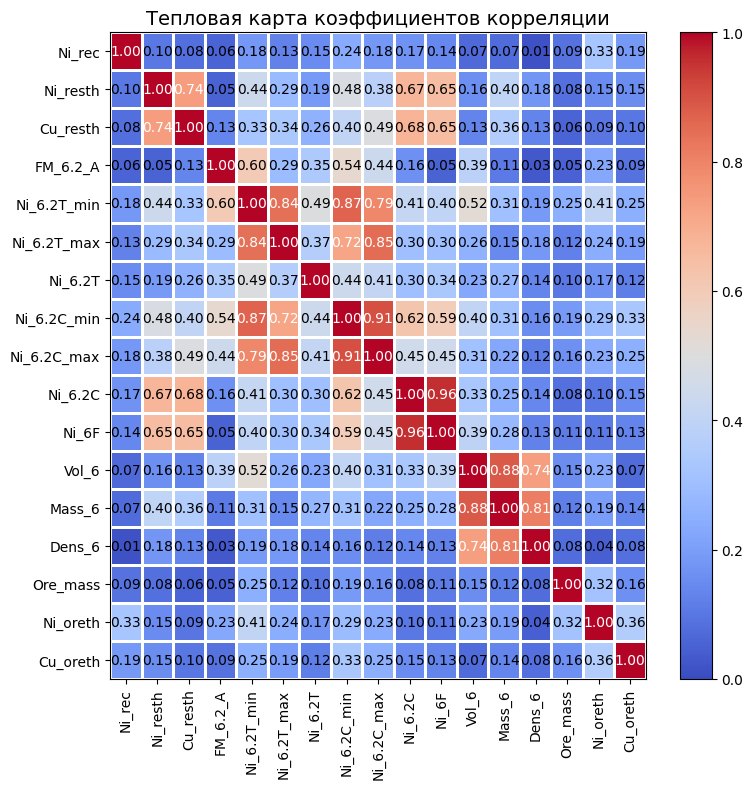

In [ ]:

for list_columns in [column_1_1, column_1_2, column_2_1, column_2_2, column_3_1, column_3_2, column_4_1, column_4_2, column_5_1, column_5_2, column_6_1, column_6_2]:
  phik_overview = data[list_columns].phik_matrix()
  phik_overview.round(2)

  plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map="coolwarm",
                        title="Тепловая карта коэффициентов корреляции",
                        fontsize_factor=1,
                        figsize=(8, 8))
  plt.tight_layout()
  plt.show()

In [ ]:
# Удаляю столбцы, которые отвечают за разные датчики
data.drop(['FM_1.1_A', 'FM_1.2_A', 'FM_2.1_A', 'FM_2.2_A','FM_3.1_A', 'FM_3.2_A', 'FM_4.1_A','FM_4.2_A', 'FM_5.1_A', 'FM_5.2_A', 'FM_6.1_A', 'FM_6.2_A'], axis=1, inplace=True)

In [ ]:
#Выбор моделей

In [ ]:
X = data.drop(['Ni_1.1C_max', 'Cu_1.1C_max',
        'Ni_1.2C_max', 'Cu_1.2C_max',
        'Cu_2.1T_max', 'Cu_2.2T_max',
        'Cu_3.1T_max', 'Cu_3.2T_max',
        'Ni_4.1T_max', 'Ni_4.1C_max',
        'Ni_4.2T_max', 'Ni_4.2C_max',
        'Ni_5.1T_max',  'Ni_5.1C_max',
        'Ni_5.2T_max', 'Ni_5.2C_max',
        'Ni_6.1T_max', 'Ni_6.1C_max',
        'Ni_6.2T_max', 'Ni_6.2C_max',
        'Ni_1.1C_min', 'Cu_1.1C_min',
        'Ni_1.2C_min', 'Cu_1.2C_min',
        'Cu_2.1T_min', 'Cu_2.2T_min',
        'Cu_3.1T_min', 'Cu_3.2T_min',
        'Ni_4.1T_min', 'Ni_4.1C_min',
        'Ni_4.2T_min', 'Ni_4.2C_min',
        'Ni_5.1T_min',  'Ni_5.1C_min',
        'Ni_5.2T_min', 'Ni_5.2C_min',
        'Ni_6.1T_min', 'Ni_6.1C_min',
        'Ni_6.2T_min', 'Ni_6.2C_min'
        ], axis=1)
y = data[
      ['Ni_1.1C_max', 'Cu_1.1C_max',
        'Ni_1.2C_max', 'Cu_1.2C_max',
        'Cu_2.1T_max', 'Cu_2.2T_max',
        'Cu_3.1T_max', 'Cu_3.2T_max',
        'Ni_4.1T_max', 'Ni_4.1C_max',
        'Ni_4.2T_max', 'Ni_4.2C_max',
        'Ni_5.1T_max',  'Ni_5.1C_max',
        'Ni_5.2T_max', 'Ni_5.2C_max',
        'Ni_6.1T_max', 'Ni_6.1C_max',
        'Ni_6.2T_max', 'Ni_6.2C_max',
        'Ni_1.1C_min', 'Cu_1.1C_min',
        'Ni_1.2C_min', 'Cu_1.2C_min',
        'Cu_2.1T_min', 'Cu_2.2T_min',
        'Cu_3.1T_min', 'Cu_3.2T_min',
        'Ni_4.1T_min', 'Ni_4.1C_min',
        'Ni_4.2T_min', 'Ni_4.2C_min',
        'Ni_5.1T_min',  'Ni_5.1C_min',
        'Ni_5.2T_min', 'Ni_5.2C_min',
        'Ni_6.1T_min', 'Ni_6.1C_min',
        'Ni_6.2T_min', 'Ni_6.2C_min'
        ]
    ]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = False)


In [ ]:
logical = LinearRegression()
logical.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred=logical.predict(X_test)
mseLog=mean_squared_error(y_test,y_pred)
maeLog=mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mseLog}")
print(f"mean_absolute_error: {maeLog}")

Mean Squared Error: 0.04038970077778618
mean_absolute_error: 0.11235971634645674


In [ ]:
y_pred[0]

array([3.23508039, 4.94709989, 3.35574293, 5.33595064, 0.40578384,
       0.51511184, 1.93649629, 1.77068486, 0.7863427 , 5.28170758,
       0.7964912 , 4.68341183, 0.75670752, 6.90941137, 0.71745071,
       6.98865659, 1.52968092, 9.81075956, 1.50384084, 9.80167507,
       2.49109562, 4.42189862, 2.80126304, 4.53746634, 0.23526246,
       0.45267577, 0.65544316, 0.62160408, 0.68458156, 4.06311999,
       0.67918078, 3.52140356, 0.5543731 , 6.11267931, 0.55277115,
       6.3647954 , 1.44063727, 8.90104864, 1.37847752, 9.20697019])

In [ ]:
y_test.iloc[0]

,2024-09-13 13:15:00
Ni_1.1C_max,3.30
Cu_1.1C_max,4.90
Ni_1.2C_max,3.40
Cu_1.2C_max,5.20
Cu_2.1T_max,0.34
Cu_2.2T_max,0.55
Cu_3.1T_max,2.00
Cu_3.2T_max,1.80
Ni_4.1T_max,0.78
Ni_4.1C_max,5.20


In [ ]:
tree=DecisionTreeRegressor(max_depth=2,min_impurity_decrease=0.2,min_samples_split=3)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, min_impurity_decrease=0.2,
                      min_samples_split=3)

In [ ]:

y_pred = tree.predict(X_test)
mseTree = mean_squared_error(y_test, y_pred)
maeTree=mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mseTree}")
print(f"mean_absolute_error: {maeTree}")

Mean Squared Error: 0.01978665231340241
mean_absolute_error: 0.10519861853757037


In [ ]:
forrest = RandomForestRegressor(max_depth=5, random_state=0)

forrest.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, random_state=0)

In [ ]:
y_pred=forrest.predict(X_test)
mseForrest=mean_squared_error(y_test,y_pred)
maeForrest=mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mseForrest}")
print(f"mean_absolute_error: {maeForrest}")

Mean Squared Error: 0.019246773476957246
mean_absolute_error: 0.07922351338097453


In [ ]:
neighbors = KNeighborsRegressor(n_neighbors=4)

neighbors.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=4)

In [ ]:
y_pred=neighbors.predict(X_test)
mseNeighbors=mean_squared_error(y_test,y_pred)
maeNeighbors=mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mseNeighbors}")
print(f"mean_absolute_error: {maeNeighbors}")

Mean Squared Error: 0.03288159668788471
mean_absolute_error: 0.12255238061928689


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(77,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(40)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=100)
predictions = model.predict(X_test)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4205.9702
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.0507
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1822
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3663
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9120
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5105
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0596
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9637
Epoch 9/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7225
Epoch 10/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6422
Epoch 11/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5813
Epoch 12/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5157
Epoch 13/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4514
Epoch 14/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4035
Epoch 15/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3

In [ ]:

mseNeur=mean_squared_error(y_test,predictions)
maeNeur=mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mseNeur}")
print(f"r2: {maeNeur}")

Mean Squared Error: 0.3445795774459839
r2: 0.12255238061928689


In [ ]:
dataResult = {'Mean Squared Error': [mseLog, mseTree, mseForrest, mseNeighbors,mseNeur],
        'Mean Absolute Error': [maeLog, maeTree, maeForrest, maeNeighbors,maeNeur],
              'Model':['logical regression', 'tree', 'random Forest', 'k-nearest neighbors'  ,'neural network']}
resultDf = pd.DataFrame(dataResult)
resultDf.set_index("Model", inplace=True)

In [ ]:
print(resultDf)

                     Mean Squared Error  Mean Absolute Error
Model                                                       
logical regression             0.040390             0.112360
tree                           0.019787             0.105199
random Forest                  0.019247             0.079224
k-nearest neighbors            0.032882             0.122552
neural network                 0.344580             0.122552
